In [ ]:
# Environment Paths & Directory Setup
import logging
from pathlib import Path
try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    has_colab = True
except Exception:
    has_colab = False

# Path Resolution
DEFAULT_COLAB_ROOT = Path("/content/drive/MyDrive/MPLADs")
ALT_COLAB_ROOT = Path("/content/drive/MYDrive/MPLADs")

if has_colab and DEFAULT_COLAB_ROOT.exists():
    PROJECT_ROOT = DEFAULT_COLAB_ROOT
elif has_colab and ALT_COLAB_ROOT.exists():
    PROJECT_ROOT = ALT_COLAB_ROOT
elif (Path.cwd() / "shared_preprocessing_artifacts").exists():
    PROJECT_ROOT = Path.cwd()
else:
    PROJECT_ROOT = Path.cwd()

SHARED_ARTIFACT_DIR = PROJECT_ROOT / "shared_preprocessing_artifacts"
FEATURE3_ARTIFACT_DIR = PROJECT_ROOT / "feature3_artifacts"
FEATURE1_ARTIFACT_DIR = PROJECT_ROOT / "feature1_artifacts"
OUTPUT_DIR = PROJECT_ROOT / "feature2_artifacts"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s"
)
logger = logging.getLogger("mplads_feature2")

logger.info("Project Root: %s", PROJECT_ROOT)
logger.info("Shared Artifacts Dir: %s", SHARED_ARTIFACT_DIR)
logger.info("Feature 3 Artifacts Dir: %s", FEATURE3_ARTIFACT_DIR)
logger.info("Feature 1 Artifacts Dir: %s", FEATURE1_ARTIFACT_DIR)
logger.info("Feature 2 Output Dir: %s", OUTPUT_DIR)


Mounted at /content/drive


In [ ]:
# Data Ingestion & Data Bus Resolution
import pandas as pd
import numpy as np

def read_artifact(dir_path: Path, name: str) -> pd.DataFrame:
    """Reads parquet artifact if available, falling back to CSV."""
    parquet_path = dir_path / f"{name}.parquet"
    csv_path = dir_path / f"{name}.csv"

    if parquet_path.exists():
        try:
            logger.info("Loading parquet: %s", parquet_path)
            return pd.read_parquet(parquet_path)
        except Exception as e:
            logger.warning("Failed loading parquet %s (%s). Falling back to CSV.", parquet_path, e)

    if csv_path.exists():
        logger.info("Loading CSV: %s", csv_path)
        return pd.read_csv(csv_path, low_memory=False)

    raise FileNotFoundError(f"Could not find {name}.parquet or {name}.csv in {dir_path}")

# Ingestion Hierarchy:
# 1. shared_preprocessing_artifacts/fact_work_feature1 (from Feature 1 output)
# 2. feature1_artifacts/feature1_fact_work_disbursement_risk
# 3. feature3_artifacts/feature3_fact_work_enriched
# 4. shared_preprocessing_artifacts/fact_work
work_df = None
source_name = ""

for dir_path, name in [
    (SHARED_ARTIFACT_DIR, "fact_work_feature1"),
    (FEATURE1_ARTIFACT_DIR, "feature1_fact_work_disbursement_risk"),
    (FEATURE3_ARTIFACT_DIR, "feature3_fact_work_enriched"),
    (SHARED_ARTIFACT_DIR, "fact_work"),
]:
    try:
        work_df = read_artifact(dir_path, name)
        source_name = f"{dir_path.name}/{name}"
        logger.info("Successfully ingested input data from %s (shape: %s)", source_name, work_df.shape)
        break
    except FileNotFoundError:
        continue

if work_df is None:
    raise FileNotFoundError("Could not locate any valid fact_work input dataset across shared and feature artifact directories.")

# Standardize key column
key_col = "work_key" if "work_key" in work_df.columns else "work_id"
if key_col not in work_df.columns:
    raise KeyError("Neither 'work_key' nor 'work_id' found in input dataset.")
if "work_key" not in work_df.columns:
    work_df["work_key"] = work_df[key_col]
if "work_id" not in work_df.columns:
    work_df["work_id"] = work_df[key_col]

logger.info("Dataset key column: %s | Total records: %d", key_col, len(work_df))


In [ ]:
# Feature Engineering & Preprocessing
df = work_df.copy()

# 1. Clean Sanction Amount & Log Transformation
df["sanction_amount"] = pd.to_numeric(df["sanction_amount"], errors="coerce")
df["valid_cost_mask"] = df["sanction_amount"].notna() & (df["sanction_amount"] > 0)

# Log transform log(1 + sanction_amount)
df["log_sanction_amount"] = np.where(
    df["valid_cost_mask"],
    np.log1p(df["sanction_amount"]),
    np.nan
)

# 2. State & Category Grouping Keys
df["state_key_clean"] = df.get("state_key", df.get("state", pd.Series("UNKNOWN_STATE", index=df.index))).fillna("UNKNOWN_STATE")
df["category_nlp_clean"] = df.get("category_nlp", pd.Series("Unclassified", index=df.index)).fillna("Unclassified")

df["peer_group_key"] = df["state_key_clean"].astype(str) + " | " + df["category_nlp_clean"].astype(str)
df["cat_group_key"] = df["category_nlp_clean"].astype(str)

# 3. Work Description Length & Token Count
desc_series = df.get("work_description", pd.Series("", index=df.index)).fillna("").astype(str)
df["desc_length_chars"] = desc_series.str.len()
df["desc_token_count"] = desc_series.str.split().str.len()

# 4. MP Recommendation Intensity / Frequency within Category
mp_col = "mp_key" if "mp_key" in df.columns else ("mp" if "mp" in df.columns else None)
if mp_col and mp_col in df.columns:
    df["mp_key_clean"] = df[mp_col].fillna("UNKNOWN_MP")
    mp_cat_counts = df.groupby(["mp_key_clean", "category_nlp_clean"])["work_key"].transform("count")
    df["mp_work_count_category"] = mp_cat_counts
else:
    df["mp_work_count_category"] = 1

df["log_mp_work_count_category"] = np.log1p(df["mp_work_count_category"])

logger.info("Preprocessing complete.")
logger.info("Valid cost records: %d / %d (%.1f%%)", df["valid_cost_mask"].sum(), len(df), df["valid_cost_mask"].mean() * 100)
logger.info("Log sanction amount range: [%.2f, %.2f]", df["log_sanction_amount"].min(), df["log_sanction_amount"].max())


In [ ]:
valid_df = df[df["valid_cost_mask"]].copy()

def calc_mad(x):
    if len(x) == 0:
        return 0.0
    med = np.median(x)
    return float(np.median(np.abs(x - med)))

def calc_p75(x):
    return float(np.percentile(x, 75)) if len(x) > 0 else np.nan

def calc_p25(x):
    return float(np.percentile(x, 25)) if len(x) > 0 else np.nan

# 1. State + Category Peer Group Statistics
peer_stats = valid_df.groupby("peer_group_key").agg(
    peer_group_size=("log_sanction_amount", "count"),
    peer_median_log_amount=("log_sanction_amount", "median"),
    peer_mad_log_amount=("log_sanction_amount", calc_mad),
    peer_median_amount=("sanction_amount", "median"),
    peer_q75_amount=("sanction_amount", calc_p75),
    peer_q25_amount=("sanction_amount", calc_p25)
).reset_index()

# Ensure string type on join keys in both DataFrames to prevent object vs category merge errors
df["peer_group_key"] = df["peer_group_key"].astype(str)
peer_stats["peer_group_key"] = peer_stats["peer_group_key"].astype(str)

# Drop pre-existing peer stats columns from df to prevent _x / _y merge suffix collisions
drop_peer_cols = [c for c in peer_stats.columns if c != "peer_group_key" and c in df.columns]
if drop_peer_cols:
    df = df.drop(columns=drop_peer_cols)

df = df.merge(peer_stats, on="peer_group_key", how="left")

# Fallback check if merge produced _x / _y suffixes
if "peer_group_size" not in df.columns and "peer_group_size_x" in df.columns:
    df = df.rename(columns={"peer_group_size_x": "peer_group_size"})

# 2. National Category Fallback Statistics
cat_stats = valid_df.groupby("cat_group_key").agg(
    cat_group_size=("log_sanction_amount", "count"),
    cat_median_log_amount=("log_sanction_amount", "median"),
    cat_mad_log_amount=("log_sanction_amount", calc_mad),
    cat_median_amount=("sanction_amount", "median")
).reset_index()

df["cat_group_key"] = df["cat_group_key"].astype(str)
cat_stats["cat_group_key"] = cat_stats["cat_group_key"].astype(str)

drop_cat_cols = [c for c in cat_stats.columns if c != "cat_group_key" and c in df.columns]
if drop_cat_cols:
    df = df.drop(columns=drop_cat_cols)

df = df.merge(cat_stats, on="cat_group_key", how="left")

if "cat_group_size" not in df.columns and "cat_group_size_x" in df.columns:
    df = df.rename(columns={"cat_group_size_x": "cat_group_size"})

# 3. Peer Group Thinness Check (Threshold < 10)
is_thin_peer_group = df["peer_group_size"].fillna(0) < 10

df["effective_peer_median_log"] = np.where(
    is_thin_peer_group,
    df["cat_median_log_amount"].fillna(0.0),
    df["peer_median_log_amount"].fillna(0.0)
)

df["effective_peer_mad_log"] = np.where(
    is_thin_peer_group,
    df["cat_mad_log_amount"].fillna(0.05),
    df["peer_mad_log_amount"].fillna(0.05)
)

df["effective_peer_median_amount"] = np.where(
    is_thin_peer_group,
    df["cat_median_amount"].fillna(100000.0),
    df["peer_median_amount"].fillna(100000.0)
)

df["cost_peer_level"] = np.where(is_thin_peer_group, "category_national", "state_category")

# Domain MAD Floor on log scale: 0.05 (~5% relative variation floor) for clean z-score scaling
mad_log_denominator = np.maximum(1.4826 * df["effective_peer_mad_log"], 0.05)

# 4. Compute Robust Cost Z-Score
df["peer_cost_zscore"] = np.where(
    df["valid_cost_mask"],
    (df["log_sanction_amount"] - df["effective_peer_median_log"]) / mad_log_denominator,
    0.0
)

# Unidirectional upper z-score (cost overrun / high sanction anomaly)
df["upper_cost_zscore"] = np.maximum(0.0, df["peer_cost_zscore"])
df["lower_cost_zscore"] = np.maximum(0.0, -df["peer_cost_zscore"])

# 5. Percentile Rank within Peer Group
df["amount_percentile_within_peer"] = np.nan
valid_indices = df[df["valid_cost_mask"]].index
df.loc[valid_indices, "amount_percentile_within_peer"] = df.loc[valid_indices].groupby("peer_group_key")["sanction_amount"].rank(pct=True) * 100.0

logger.info("Robust statistical peer scoring completed. Evaluated %d unique peer groups.", df["peer_group_key"].nunique())

In [ ]:
# Multivariate Local Outlier Factor (LOF) Anomaly Detection
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
import joblib

logger.info("--- Starting Multivariate Local Outlier Factor (LOF) Pipeline ---")

# Assemble feature matrix for LOF
lof_feature_cols = [
    "log_sanction_amount",
    "desc_token_count",
    "peer_cost_zscore",
    "log_mp_work_count_category"
]

logger.info("Multivariate features used for LOF: %s", lof_feature_cols)

valid_cost_mask = df["valid_cost_mask"].values
X_raw = df.loc[valid_cost_mask, lof_feature_cols].copy()

# Impute & Scale Features
imputer = SimpleImputer(strategy="median")
scaler = RobustScaler()

X_imputed = imputer.fit_transform(X_raw)
X_scaled = scaler.fit_transform(X_imputed)

# Fit Local Outlier Factor (LOF) with novelty=True for out-of-sample scoring support
lof_model = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.03,
    novelty=True,
    n_jobs=-1
)
lof_model.fit(X_scaled)

# Score samples: LocalOutlierFactor outputs lower/negative scores for anomalies.
# Invert score so HIGHER value means MORE ANOMALOUS.
raw_lof_scores = -lof_model.score_samples(X_scaled)

# Scale score to [0.0, 1.0] range
score_min, score_max = raw_lof_scores.min(), raw_lof_scores.max()
if score_max > score_min:
    norm_lof_scores = (raw_lof_scores - score_min) / (score_max - score_min)
else:
    norm_lof_scores = np.zeros_like(raw_lof_scores)

# Assign LOF anomaly score back to dataframe
df["lof_anomaly_score"] = np.nan
df.loc[valid_cost_mask, "lof_anomaly_score"] = norm_lof_scores

# Save trained LOF model & pipeline artifacts
lof_model_path = OUTPUT_DIR / "feature2_lof_model.joblib"
joblib.dump({
    "imputer": imputer,
    "scaler": scaler,
    "model": lof_model,
    "feature_cols": lof_feature_cols,
    "score_min": float(score_min),
    "score_max": float(score_max)
}, lof_model_path)

logger.info("LOF model trained on %d valid cost records and saved to %s", valid_cost_mask.sum(), lof_model_path)


In [ ]:
# Cost Anomaly Rules & Unified Blended Cost Risk Score

# 1. Sanction-to-Peer-Median Ratio
df["sanction_peer_ratio"] = np.where(
    df["valid_cost_mask"] & (df["effective_peer_median_amount"] > 0),
    df["sanction_amount"] / df["effective_peer_median_amount"],
    1.0
)

# 2. Rule Flags
# High cost on vague/short description (sanction > 1,000,000 and token count < 5)
df["is_vague_high_cost"] = df["valid_cost_mask"] & (df["sanction_amount"] >= 1000000.0) & (df["desc_token_count"] < 5)
df["is_extreme_peer_overrun"] = df["valid_cost_mask"] & (df["sanction_peer_ratio"] >= 3.0)

# 3. Normalized Sub-scores [0.0, 1.0]
z_norm = np.clip(df["upper_cost_zscore"] / 4.0, 0.0, 1.0)
ratio_norm = np.clip((df["sanction_peer_ratio"] - 1.0) / 4.0, 0.0, 1.0)
lof_norm = df["lof_anomaly_score"].fillna(0.0)

vague_desc_boost = np.where(df["is_vague_high_cost"], 0.15, 0.0)

# Unified Blended Cost Risk Score [0.0 - 1.0]
# Weights: 40% Peer Z-Score + 35% LOF Multivariate Anomaly + 15% Peer Ratio + Vague Description Boost
df["cost_risk_score"] = np.where(
    df["valid_cost_mask"],
    np.clip(0.40 * z_norm + 0.35 * lof_norm + 0.15 * ratio_norm + vague_desc_boost, 0.0, 1.0),
    np.nan
)

# Risk Tier Categorization
def assign_cost_risk_tier(row: pd.Series) -> str:
    if not row["valid_cost_mask"]:
        return "Unknown / Invalid"

    score = row["cost_risk_score"]
    zscore = row["upper_cost_zscore"]
    ratio = row["sanction_peer_ratio"]

    if score >= 0.70 or (zscore >= 4.0 and ratio >= 3.0):
        return "Critical"
    elif score >= 0.50 or zscore >= 2.5:
        return "High"
    elif score >= 0.30:
        return "Medium"
    else:
        return "Low"

df["cost_risk_tier"] = df.apply(assign_cost_risk_tier, axis=1)

print("--- Feature 2 Cost Risk Tier Distribution ---")
print(df["cost_risk_tier"].value_counts(dropna=False))


--- Feature 2 Cost Risk Tier Distribution ---
cost_risk_tier
Low                  29493
Unknown / Invalid     9150
Medium                1910
High                  1698
Critical               899
Name: count, dtype: int64


In [ ]:
# Dashboard Explanation Generator

def generate_cost_dashboard_explanation(row: pd.Series) -> str:
    """Generates clear, natural language explanation strings for cost anomaly dashboard display."""
    if not row["valid_cost_mask"]:
        return "Cost status unknown: Missing or non-positive sanction amount recorded."

    sanction = row["sanction_amount"]
    peer_median = row["effective_peer_median_amount"]
    ratio = row["sanction_peer_ratio"]
    zscore = row["upper_cost_zscore"]
    lof_score = row.get("lof_anomaly_score", np.nan)
    state = row["state_key_clean"]
    cat = row["category_nlp_clean"]
    tier = row["cost_risk_tier"]

    z_str = f">{10.0:.1f}σ" if zscore >= 10.0 else f"{zscore:.1f}σ"
    lof_note = f" (Multivariate LOF anomaly score: {lof_score:.2f})" if pd.notna(lof_score) and lof_score >= 0.60 else ""

    if tier == "Critical":
        return (
            f"CRITICAL COST ANOMALY: Sanctioned amount ₹{sanction:,.0f} is {ratio:.1f}x higher than the "
            f"{state} ({cat}) peer median (₹{peer_median:,.0f}). Exceeds expected peer median by {z_str}.{lof_note}"
        )
    elif tier == "High":
        return (
            f"HIGH COST OVERRUN: Sanctioned amount ₹{sanction:,.0f} exceeds {state} ({cat}) "
            f"peer median of ₹{peer_median:,.0f} by {z_str} ({ratio:.1f}x peer benchmark).{lof_note}"
        )
    elif pd.notna(lof_score) and lof_score >= 0.70 and zscore < 2.0:
        return (
            f"MULTIVARIATE COST ANOMALY DETECTED: Project displays unusual combination of cost, description length, "
            f"and MP recommendation frequency (LOF Anomaly Score: {lof_score:.2f}) despite moderate univariate cost z-score."
        )
    elif tier == "Medium":
        return (
            f"MODERATE COST VARIANCE: Sanctioned amount ₹{sanction:,.0f} is {ratio:.1f}x relative to "
            f"peer group median ₹{peer_median:,.0f} ({z_str} above peer median).{lof_note}"
        )
    else:
        return (
            f"NORMAL COST BENCHMARK: Sanctioned amount ₹{sanction:,.0f} is within normal expectation for "
            f"{state} ({cat}) (Peer median: ₹{peer_median:,.0f})."
        )

df["cost_risk_explanation"] = df.apply(generate_cost_dashboard_explanation, axis=1)

print("--- Sample Critical Cost Dashboard Explanations ---")
critical_samples = df[df["cost_risk_tier"] == "Critical"]["cost_risk_explanation"].head(5)
for i, exp in enumerate(critical_samples, 1):
    print(f"{i}. {exp}\n")


--- Sample Critical Cost Dashboard Explanations ---
1. CRITICAL COST ANOMALY: Sanctioned amount ₹3,389,297 is 3.4x higher than the Tamil Nadu (Road & Pathway Infrastructure) peer median (₹996,064). Exceeds expected peer median by >10.0σ.

2. CRITICAL COST ANOMALY: Sanctioned amount ₹1,999,306 is 4.0x higher than the Andhra Pradesh (Road & Pathway Infrastructure) peer median (₹498,526). Exceeds expected peer median by >10.0σ.

3. CRITICAL COST ANOMALY: Sanctioned amount ₹1,954,710 is 3.9x higher than the Andhra Pradesh (Road & Pathway Infrastructure) peer median (₹498,526). Exceeds expected peer median by >10.0σ.

4. CRITICAL COST ANOMALY: Sanctioned amount ₹11,586,983 is 23.2x higher than the Andhra Pradesh (Road & Pathway Infrastructure) peer median (₹498,526). Exceeds expected peer median by >10.0σ.

5. CRITICAL COST ANOMALY: Sanctioned amount ₹7,000,000 is 14.0x higher than the Andhra Pradesh (Road & Pathway Infrastructure) peer median (₹498,526). Exceeds expected peer median by >10

In [ ]:
# Summary Analysis & Top Anomaly Worklist Display

display_cols = [
    "work_id", "state_key_clean", "category_nlp_clean", "sanction_amount",
    "effective_peer_median_amount", "sanction_peer_ratio", "peer_cost_zscore",
    "lof_anomaly_score", "cost_risk_score", "cost_risk_tier", "cost_risk_explanation"
]

critical_cost_worklist = df[df["cost_risk_tier"] == "Critical"].sort_values(
    by=["cost_risk_score", "sanction_peer_ratio"],
    ascending=[False, False]
)

print(f"Total Critical Cost Anomalies Identified: {len(critical_cost_worklist)}")
print("\n--- Top 10 Critical Sanction-Amount Cost Anomalies ---")
if len(critical_cost_worklist) > 0:
    display_df = critical_cost_worklist[display_cols].head(10)
    try:
        from IPython.display import display
        display(display_df)
    except Exception:
        print(display_df.to_string())


Total Critical Cost Anomalies Identified: 899

--- Top 10 Critical Sanction-Amount Cost Anomalies ---


,work_id,state_key_clean,category_nlp_clean,sanction_amount,effective_peer_median_amount,sanction_peer_ratio,peer_cost_zscore,lof_anomaly_score,cost_risk_score,cost_risk_tier,cost_risk_explanation
17105,WS/MP334/2024-2025/140580,Jharkhand,Street Lighting & Solar Energy,198000.0,22000.0,9.000000,43.943683,1.000000,0.900000,Critical,"CRITICAL COST ANOMALY: Sanctioned amount ₹198,..."
17135,WS/MP334/2024-2025/143388,Jharkhand,Street Lighting & Solar Energy,198000.0,22000.0,9.000000,43.943683,1.000000,0.900000,Critical,"CRITICAL COST ANOMALY: Sanctioned amount ₹198,..."
17171,WS/MP334/2024-2025/144867,Jharkhand,Street Lighting & Solar Energy,198000.0,22000.0,9.000000,43.943683,1.000000,0.900000,Critical,"CRITICAL COST ANOMALY: Sanctioned amount ₹198,..."
30995,WS/MP140/2024-2025/156049,Punjab,Drinking Water Infrastructure,1500000.0,365800.0,4.100601,11.319727,0.590960,0.873108,Critical,"CRITICAL COST ANOMALY: Sanctioned amount ₹1,50..."
17131,WS/MP334/2024-2025/143361,Jharkhand,Street Lighting & Solar Energy,132000.0,22000.0,6.000000,35.834432,0.781506,0.823527,Critical,"CRITICAL COST ANOMALY: Sanctioned amount ₹132,..."
17136,WS/MP334/2024-2025/143389,Jharkhand,Street Lighting & Solar Energy,132000.0,22000.0,6.000000,35.834432,0.781506,0.823527,Critical,"CRITICAL COST ANOMALY: Sanctioned amount ₹132,..."
17140,WS/MP334/2024-2025/143398,Jharkhand,Street Lighting & Solar Energy,132000.0,22000.0,6.000000,35.834432,0.781506,0.823527,Critical,"CRITICAL COST ANOMALY: Sanctioned amount ₹132,..."
17101,WS/MP334/2024-2025/140556,Jharkhand,Street Lighting & Solar Energy,176000.0,22000.0,8.000000,41.588035,0.753853,0.813849,Critical,"CRITICAL COST ANOMALY: Sanctioned amount ₹176,..."
17103,WS/MP334/2024-2025/140558,Jharkhand,Street Lighting & Solar Energy,176000.0,22000.0,8.000000,41.588035,0.753853,0.813849,Critical,"CRITICAL COST ANOMALY: Sanctioned amount ₹176,..."
17109,WS/MP334/2024-2025/140585,Jharkhand,Street Lighting & Solar Energy,176000.0,22000.0,8.000000,41.588035,0.753853,0.813849,Critical,"CRITICAL COST ANOMALY: Sanctioned amount ₹176,..."


/tmp/ipykernel_2837/4212903487.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_2837/4212903487.py:117: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_2837/4212903487.py:119: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  plt.savefig(fig_path, dpi=300, bbox_inches="tight")
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


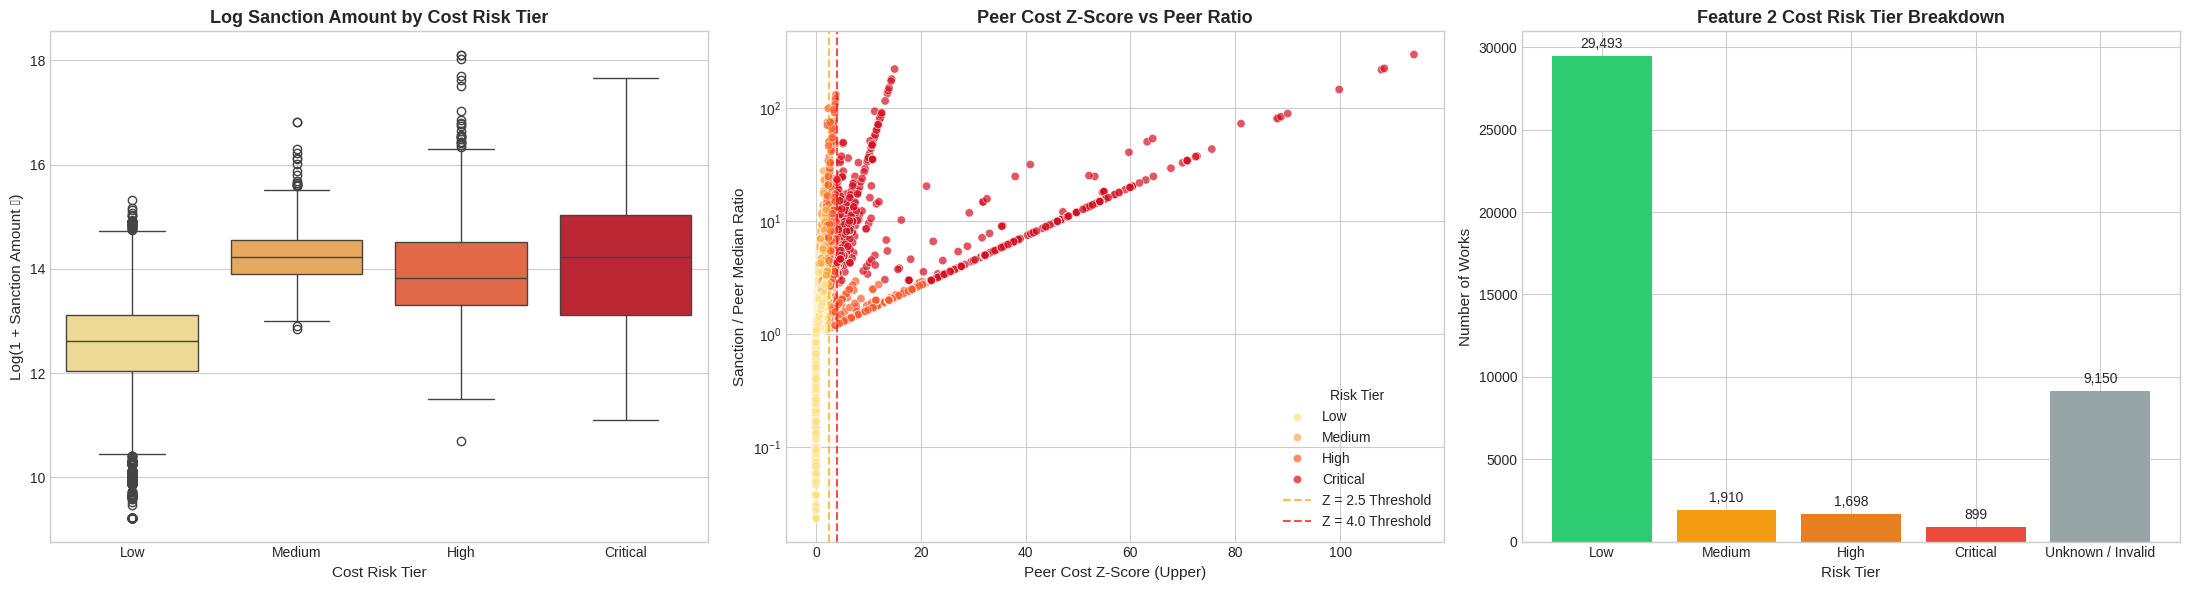


  FEATURE 2 COST BENCHMARKING PIPELINE COMPLETE
Artifacts exported to: /content/drive/MyDrive/MPLADs/feature2_artifacts
Canonical Data Bus updated at: /content/drive/MyDrive/MPLADs/shared_preprocessing_artifacts/fact_work_feature2.parquet


In [ ]:
# Artifact Export & Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import json
from datetime import datetime

# Canonical Fact Table in shared_preprocessing_artifacts/
shared_parquet_path = SHARED_ARTIFACT_DIR / "fact_work_feature2.parquet"
shared_csv_path = SHARED_ARTIFACT_DIR / "fact_work_feature2.csv"

try:
    logger.info("Exporting canonical fact_work_feature2 to %s", shared_parquet_path)
    df.to_parquet(shared_parquet_path, index=False)
except Exception as e:
    logger.warning("Failed saving parquet to shared artifacts (%s). Saving CSV.", e)

df.to_csv(shared_csv_path, index=False)
logger.info("Saved CSV: %s", shared_csv_path)

# 2. Export Feature 2 Specific Artifacts
feat2_parquet_path = OUTPUT_DIR / "feature2_fact_work_cost_risk.parquet"
feat2_csv_path = OUTPUT_DIR / "feature2_fact_work_cost_risk.csv"

try:
    df.to_parquet(feat2_parquet_path, index=False)
except Exception:
    pass
df.to_csv(feat2_csv_path, index=False)
logger.info("Exported Feature 2 work dataset to %s", feat2_csv_path)

# Export Filtered Critical & High Worklist for Audit Triage
triage_mask = df["cost_risk_tier"].isin(["Critical", "High"])
triage_worklist = df[triage_mask].sort_values(by=["cost_risk_score"], ascending=False)
triage_csv_path = OUTPUT_DIR / "feature2_cost_risk_worklist.csv"
triage_worklist.to_csv(triage_csv_path, index=False)
logger.info("Exported %d triage worklist items to %s", len(triage_worklist), triage_csv_path)

# Export Execution Run Metadata JSON
tier_counts = df["cost_risk_tier"].value_counts().to_dict()
metadata = {
    "feature": "Feature 2 - Cost Benchmarking & Sanction-Amount Anomaly Detection",
    "run_timestamp": datetime.now().isoformat(),
    "total_records_processed": int(len(df)),
    "valid_cost_records": int(df["valid_cost_mask"].sum()),
    "unique_peer_groups": int(df["peer_group_key"].nunique()),
    "risk_tier_counts": {str(k): int(v) for k, v in tier_counts.items()},
    "lof_parameters": {
        "n_neighbors": 20,
        "contamination": 0.03,
        "novelty": True
    },
    "exported_artifacts": [
        str(shared_parquet_path.name),
        str(feat2_parquet_path.name),
        str(triage_csv_path.name),
        "feature2_lof_model.joblib",
        "feature2_cost_distribution.png"
    ]
}

metadata_path = OUTPUT_DIR / "feature2_run_metadata.json"
with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=2)
logger.info("Saved metadata JSON to %s", metadata_path)

# 3. Generate 3-Panel Visualization Figure
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Panel 1: Log Sanction Amount Distribution by Risk Tier
valid_plot_df = df[df["valid_cost_mask"]].copy()
sns.boxplot(
    data=valid_plot_df,
    x="cost_risk_tier",
    y="log_sanction_amount",
    order=["Low", "Medium", "High", "Critical"],
    ax=axes[0],
    palette="YlOrRd"
)
axes[0].set_title("Log Sanction Amount by Cost Risk Tier", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Cost Risk Tier", fontsize=11)
axes[0].set_ylabel("Log(1 + Sanction Amount ₹)", fontsize=11)

# Panel 2: Peer Ratio vs Robust Cost Z-Score Scatter
sns.scatterplot(
    data=valid_plot_df,
    x="upper_cost_zscore",
    y="sanction_peer_ratio",
    hue="cost_risk_tier",
    hue_order=["Low", "Medium", "High", "Critical"],
    palette="YlOrRd",
    alpha=0.7,
    ax=axes[1]
)
axes[1].axvline(2.5, color="orange", linestyle="--", alpha=0.7, label="Z = 2.5 Threshold")
axes[1].axvline(4.0, color="red", linestyle="--", alpha=0.7, label="Z = 4.0 Threshold")
axes[1].set_title("Peer Cost Z-Score vs Peer Ratio", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Peer Cost Z-Score (Upper)", fontsize=11)
axes[1].set_ylabel("Sanction / Peer Median Ratio", fontsize=11)
axes[1].set_yscale("log")
axes[1].legend(title="Risk Tier")

# Panel 3: Risk Tier Counts Bar Chart
tier_order = ["Low", "Medium", "High", "Critical", "Unknown / Invalid"]
present_tiers = [t for t in tier_order if t in tier_counts]
counts = [tier_counts.get(t, 0) for t in present_tiers]

bars = axes[2].bar(present_tiers, counts, color=["#2ecc71", "#f39c12", "#e67e22", "#e74c3c", "#95a5a6"][:len(present_tiers)])
axes[2].set_title("Feature 2 Cost Risk Tier Breakdown", fontsize=13, fontweight="bold")
axes[2].set_xlabel("Risk Tier", fontsize=11)
axes[2].set_ylabel("Number of Works", fontsize=11)

for bar in bars:
    yval = bar.get_height()
    axes[2].text(bar.get_x() + bar.get_width()/2.0, yval + max(counts)*0.01, f"{yval:,}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
fig_path = OUTPUT_DIR / "feature2_cost_distribution.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()
logger.info("Generated and saved visualization figure to %s", fig_path)

print("\n=======================================================")
print("  FEATURE 2 COST BENCHMARKING PIPELINE COMPLETE")
print("=======================================================")
print(f"Artifacts exported to: {OUTPUT_DIR}")
print(f"Canonical Data Bus updated at: {shared_parquet_path}")


/tmp/ipykernel_2837/949866736.py:33: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_2837/949866736.py:35: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  plt.savefig(fig1_path, dpi=300, bbox_inches="tight")
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


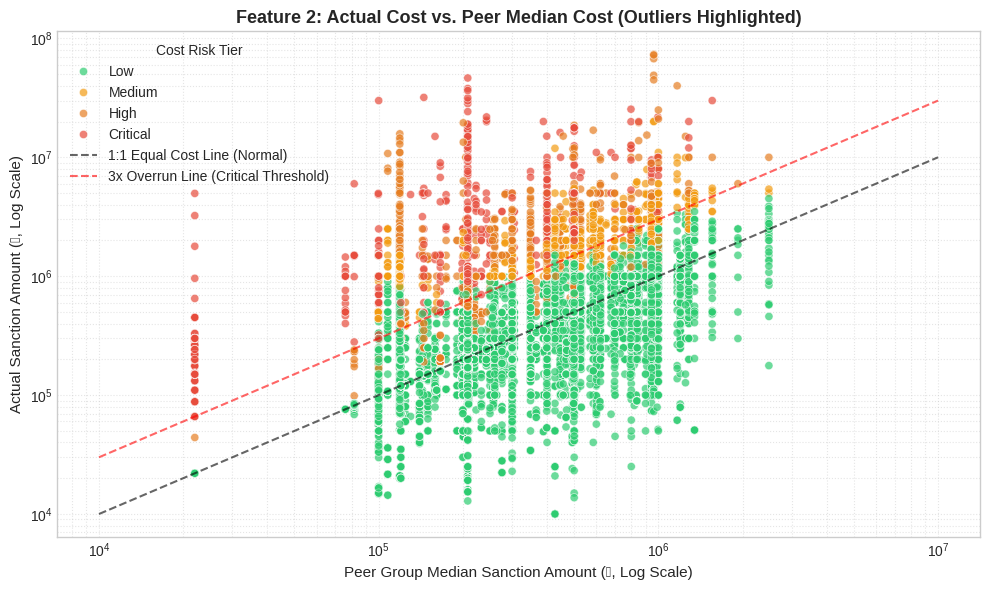

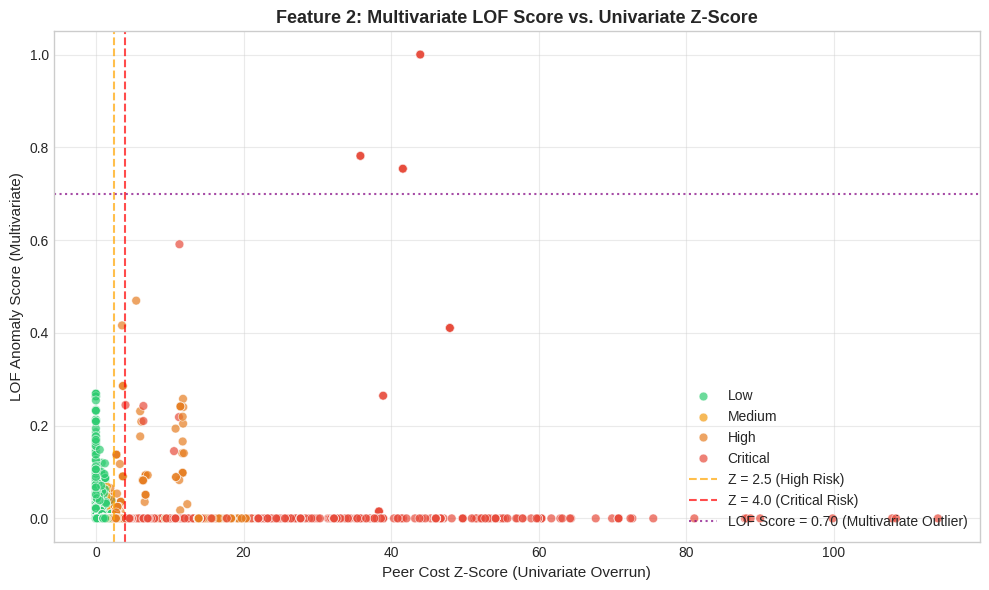

/tmp/ipykernel_2837/949866736.py:100: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_2837/949866736.py:102: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  plt.savefig(fig3_path, dpi=300, bbox_inches="tight")
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


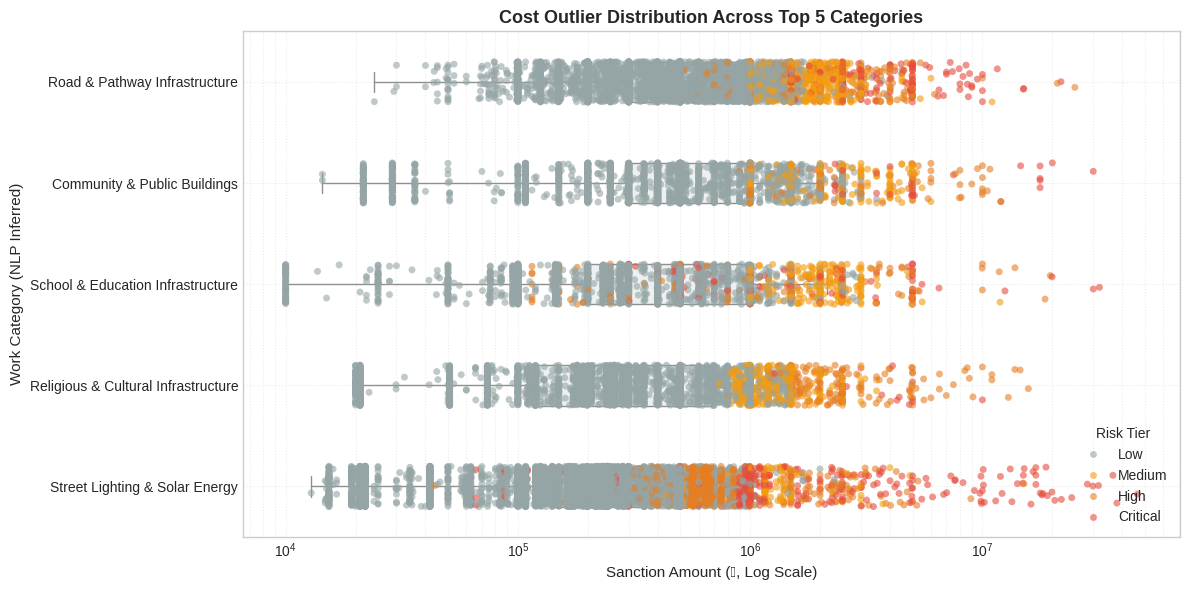

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plot_df = df[df["valid_cost_mask"]].copy()

# Plot 1: Actual Cost vs Peer Median Cost (Log-Log Parity Plot)
fig1, ax1 = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=plot_df,
    x="effective_peer_median_amount",
    y="sanction_amount",
    hue="cost_risk_tier",
    hue_order=["Low", "Medium", "High", "Critical"],
    palette={"Low": "#2ecc71", "Medium": "#f39c12", "High": "#e67e22", "Critical": "#e74c3c"},
    alpha=0.7,
    s=35,
    ax=ax1
)

x_vals = np.logspace(4, 7, 100)
ax1.plot(x_vals, x_vals, 'k--', alpha=0.6, label="1:1 Equal Cost Line (Normal)")
ax1.plot(x_vals, 3 * x_vals, 'r--', alpha=0.6, label="3x Overrun Line (Critical Threshold)")

ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel("Peer Group Median Sanction Amount (₹, Log Scale)", fontsize=11)
ax1.set_ylabel("Actual Sanction Amount (₹, Log Scale)", fontsize=11)
ax1.set_title("Feature 2: Actual Cost vs. Peer Median Cost (Outliers Highlighted)", fontsize=13, fontweight="bold")
ax1.legend(title="Cost Risk Tier", loc="upper left")
ax1.grid(True, which="both", linestyle=":", alpha=0.5)
plt.tight_layout()
fig1_path = OUTPUT_DIR / "feature2_parity_outliers.png"
plt.savefig(fig1_path, dpi=300, bbox_inches="tight")
plt.show()

# Plot 2: Multivariate LOF Score vs Peer Cost Z-Score
fig2, ax2 = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=plot_df,
    x="upper_cost_zscore",
    y="lof_anomaly_score",
    hue="cost_risk_tier",
    hue_order=["Low", "Medium", "High", "Critical"],
    palette={"Low": "#2ecc71", "Medium": "#f39c12", "High": "#e67e22", "Critical": "#e74c3c"},
    alpha=0.7,
    s=40,
    ax=ax2
)

ax2.axvline(2.5, color="orange", linestyle="--", alpha=0.7, label="Z = 2.5 (High Risk)")
ax2.axvline(4.0, color="red", linestyle="--", alpha=0.7, label="Z = 4.0 (Critical Risk)")
ax2.axhline(0.70, color="purple", linestyle=":", alpha=0.7, label="LOF Score = 0.70 (Multivariate Outlier)")

ax2.set_xlabel("Peer Cost Z-Score (Univariate Overrun)", fontsize=11)
ax2.set_ylabel("LOF Anomaly Score (Multivariate)", fontsize=11)
ax2.set_title("Feature 2: Multivariate LOF Score vs. Univariate Z-Score", fontsize=13, fontweight="bold")
ax2.legend(loc="lower right")
ax2.grid(True, alpha=0.4)
plt.tight_layout()
fig2_path = OUTPUT_DIR / "feature2_lof_vs_zscore.png"
plt.savefig(fig2_path, dpi=300, bbox_inches="tight")
plt.show()

# Plot 3: Category-Wise Outlier Distribution (Top Categories Strip Plot)
top_categories = plot_df["category_nlp_clean"].value_counts().head(5).index
cat_df = plot_df[plot_df["category_nlp_clean"].isin(top_categories)].copy()

fig3, ax3 = plt.subplots(figsize=(12, 6))
sns.boxplot(
    data=cat_df,
    y="category_nlp_clean",
    x="sanction_amount",
    color="#ecf0f1",
    fliersize=0,
    width=0.4,
    ax=ax3
)

sns.stripplot(
    data=cat_df,
    y="category_nlp_clean",
    x="sanction_amount",
    hue="cost_risk_tier",
    hue_order=["Low", "Medium", "High", "Critical"],
    palette={"Low": "#95a5a6", "Medium": "#f39c12", "High": "#e67e22", "Critical": "#e74c3c"},
    alpha=0.6,
    jitter=0.2,
    size=5,
    ax=ax3
)

ax3.set_xscale("log")
ax3.set_xlabel("Sanction Amount (₹, Log Scale)", fontsize=11)
ax3.set_ylabel("Work Category (NLP Inferred)", fontsize=11)
ax3.set_title("Cost Outlier Distribution Across Top 5 Categories", fontsize=13, fontweight="bold")
ax3.legend(title="Risk Tier", loc="lower right")
ax3.grid(True, which="both", linestyle=":", alpha=0.4)
plt.tight_layout()
fig3_path = OUTPUT_DIR / "feature2_category_outliers.png"
plt.savefig(fig3_path, dpi=300, bbox_inches="tight")
plt.show()

logger.info("Generated and saved outlier visualization plots to %s, %s, %s", fig1_path, fig2_path, fig3_path)